<a href="https://colab.research.google.com/github/Berkaycetinn/SoftITo/blob/main/ML_03.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

* warnings → Uyarıları yönetir.
* numpy (np) → Sayısal işlemler yapar.
* pandas (pd) → Tablo/veri analizi yapar.
* matplotlib (plt) → Grafik çizer.
* seaborn (sns) → İstatistiksel grafikler çizer.
* scipy.stats → İstatistiksel testler yapar.
* statsmodels (sm) → İstatistiksel modeller kurar.
* smf → Formülle model kurar.
* VIF → Değişkenler arasındaki bağlantıyı kontrol eder.
* Tukey → Gruplar arasındaki farkları karşılaştırır.
* StandardScaler → Verileri standartlaştırır.
* PCA → Boyut azaltır.

In [2]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor as VIF
from statsmodels.stats.multicomp import pairwise_tukeyhsd

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

1000 müşterilik sahte bir veri oluşturuyoruz → bazı eksik değerler ve aykırı değerler ekliyoruz → birkaç satırı tekrar ediyoruz → sonra bu veriyi temizlemeye/analiz etmeye hazırlanıyoruz.

In [3]:
n = 1000

gelir = np.random.lognormal(mean=10.5, sigma=0.6, size=n) #sigma = sayılar birbirine ne kadar yakın olsun
memnuniyet = np.random.choice([1, 2, 3, 4, 5], size=n, p=[0.05, 0.1, 0.2, 0.35, 0.3]) #p ile hepsinin seçilme ihtimali verdik
gurultu = np.random.normal(0, 80, n)

aylik_harcama = (0.004 * gelir + 15 * memnuniyet + gurultu).clip(min=10) # clip ile harcama 10 dan küçükse 10 yap diyoruz.

df = pd.DataFrame({
    "musteri_id": range(1, n + 1),
    "yas": np.random.normal(38, 12, n).round(0), #round(0) ile ondalık kısmı kaldırdık
    "gelir": gelir.round(2),
    "sehir": np.random.choice(
        ["İstanbul", "Ankara", "İzmir", "Bursa", "istanbul", "ANKARA"], #Veri temizliği yapmak için şehirlerin harflerini büyük küçük olarak değiştirdik
        size=n, p=[0.35, 0.2, 0.15, 0.1, 0.1, 0.1]
    ),
    "abonelik_tipi": np.random.choice(["Temel", "Standart", "Premium"], size=n, p=[0.5, 0.35, 0.15]),
    "aylik_harcama": aylik_harcama.round(2),
    "memnuniyet_puani": memnuniyet.astype(float),
    "churn": np.random.choice([0, 1], size=n, p=[0.8, 0.2]), #Müşterileirn aboneliği bırakıp bırakmadığı
})
df

,musteri_id,yas,gelir,sehir,abonelik_tipi,aylik_harcama,memnuniyet_puani,churn
0,1,33.0,35328.36,İzmir,Temel,186.62,5.0,0
1,2,37.0,29944.16,İzmir,Standart,129.56,4.0,0
2,3,51.0,31680.48,İstanbul,Temel,10.00,2.0,0
3,4,36.0,33216.58,istanbul,Temel,243.41,4.0,1
4,5,35.0,63945.51,İstanbul,Standart,368.82,2.0,0
...,...,...,...,...,...,...,...,...
995,996,68.0,17183.73,İstanbul,Temel,177.15,5.0,0
996,997,52.0,22052.41,İzmir,Temel,158.43,4.0,0
997,998,59.0,50316.66,Ankara,Standart,279.97,3.0,0
998,999,23.0,145538.79,İstanbul,Temel,670.75,3.0,0


In [4]:
# Kasıtlı bozulmalar

#Gelir sütunundaki müşterilerin %8'ini boş yapmak.
df.loc[df.sample(frac=0.08, random_state=1).index, "gelir"] = np.nan

#Yaşların %5'ini boşaltıyoruz.
df.loc[df.sample(frac=0.05, random_state=2).index, "yas"] = np.nan

# %1lik kısma aykırı değer (outlier) yapıyoruz
outlier_idx = df.sample(frac=0.01, random_state=4).index
df.loc[outlier_idx, "gelir"] = df["gelir"].max() * np.random.uniform(3, 6, len(outlier_idx))

#DataFrame'den 5 tane rastgele satır seçiyoruz, sonra bu 5 satırı tekrar DataFrame'in altına ekliyoruz. duplicate (tekrarlanan kayıtlar)
df = pd.concat([df, df.sample(5, random_state=7)], ignore_index=True)

sayisal_sutunlar = ["yas", "gelir", "aylik_harcama", "memnuniyet_puani"]
kategorik_sutunlar = ["sehir", "abonelik_tipi", "churn"]

print(f"Veri seti: {df.shape[0]} satır, {df.shape[1]} sütun")
df.head(7)

Veri seti: 1005 satır, 8 sütun


,musteri_id,yas,gelir,sehir,abonelik_tipi,aylik_harcama,memnuniyet_puani,churn
0,1,33.0,35328.36,İzmir,Temel,186.62,5.0,0
1,2,37.0,29944.16,İzmir,Standart,129.56,4.0,0
2,3,51.0,31680.48,İstanbul,Temel,10.00,2.0,0
3,4,36.0,33216.58,istanbul,Temel,243.41,4.0,1
4,5,35.0,63945.51,İstanbul,Standart,368.82,2.0,0
5,6,55.0,25832.71,İzmir,Temel,164.65,4.0,0
6,7,33.0,NaN,İzmir,Standart,554.09,4.0,1


In [5]:
#Genel Bakış
ozet = pd.DataFrame({
    "dtype": df.dtypes,
    "n_unique": df.nunique(),
    "eksik_değer":df.isnull().sum(),
    "eksik_değer_yüzdesi":(df.isnull().mean()*100).round(2)
})

ozet

,dtype,n_unique,eksik_değer,eksik_değer_yüzdesi
musteri_id,int64,1000,0,0.00
yas,float64,68,50,4.98
gelir,float64,921,79,7.86
sehir,object,6,0,0.00
abonelik_tipi,object,3,0,0.00
aylik_harcama,float64,950,0,0.00
memnuniyet_puani,float64,5,0,0.00
churn,int64,2,0,0.00


In [6]:
#Tekrar eden
print("tekrar eden satır:", df.duplicated().sum())
df["sehir"] = df["sehir"].str.strip().str.title().replace({"Istanbul": "İstanbul"}) #strip ile başında sonunda boşluk varsa siliyoruz. title ile ilk harfleri büyük yapıyoruz
print(df["sehir"].value_counts())

tekrar eden satır: 5
sehir
İstanbul    438
Ankara      300
İzmir       173
Bursa        94
Name: count, dtype: int64


In [7]:
#Sayısal sütunların ortalamasını buluyor ve bu ortalamanın %95 güven aralığını hesaplıyor.
def ortalama_guven_aralığı(seri,guven=0.95):
  veri = seri.dropna()
  n = len(veri)
  ortalama = veri.mean()
  sem = stats.sem(veri) # standart error of the mean
  t_kritik = stats.t.ppf((1+guven)/2 ,df =n-1) # df=degrees of freedom = serbestlik derecesi
  hata_payi = t_kritik*sem
  return ortalama,ortalama-hata_payi,ortalama+hata_payi

print(f"{'değişken':20s},{'Ortalama':>12s},{'%95 Alt':>12s},{'%95 Üst':>12s}")
for degisken in sayisal_sutunlar:
  ortalama,alt,ust = ortalama_guven_aralığı(df[degisken])
  print(f"{degisken:20s},{ortalama:>12.2f},{alt:>12.2f},{ust:>12.2f}")

değişken            ,    Ortalama,     %95 Alt,     %95 Üst
yas                 ,       38.28,       37.51,       39.05
gelir               ,    59847.90,    49658.71,    70037.08
aylik_harcama       ,      233.83,      224.99,      242.66
memnuniyet_puani    ,        3.78,        3.71,        3.85


In [8]:
betimsel = df[sayisal_sutunlar].describe().T #T tabloyu transpoze eder, yani satırları ve sütunları yer değiştirir.
betimsel["skew"] = df[sayisal_sutunlar].skew() #Bir dağılımın sağa mı sola mı yatık olduğunu anlamamıza yardımcı olur.birkaç tane çok yüksek değer varsa, dağılımın sağ tarafı uzar.
betimsel["kurtosis"] = df[sayisal_sutunlar].kurtosis() #Bu değer dağılımın kuyruklarının ve uç değerlerinin nasıl olduğunu anlamamıza yardımcı olur.
betimsel.round(2)

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
yas,955.0,38.28,12.12,-3.00,30.00,38.00,47.00,80.00,0.08,-0.01
gelir,926.0,59847.90,157989.43,4287.38,24230.34,36130.54,55364.93,1878890.17,9.26,88.34
aylik_harcama,1005.0,233.83,142.72,10.00,135.65,216.67,307.74,1457.63,1.53,6.91
memnuniyet_puani,1005.0,3.78,1.14,1.00,3.00,4.00,5.00,5.00,-0.78,-0.15


In [9]:
print(f"{'Değişken':20s} {'Shapiro-Wilk p':>16s} {'DAgostino p'} Yorum ")
for col in sayisal_sutunlar:
  veri= df[col].dropna()
  # shapiro n> 5000 den fazla olursa güvenilmez olur
  ornek = veri.sample(min(len(veri),5000),random_state=0)
  sw_stat, sw_p = stats.shapiro(ornek)
  da_stat, da_p = stats.normaltest(veri)
  yorum = "Normal dağılım varsayımı sağlanmaktadır." if sw_p > 0.05 else "Normal dağılım varsayımı sağlanmamaktadır."
  print(f"{col:20s} {sw_p:>16.4f} {da_p:>16.4f} {yorum}")

Değişken               Shapiro-Wilk p DAgostino p Yorum 
yas                            0.6787           0.5858 Normal dağılım varsayımı sağlanmaktadır.
gelir                          0.0000           0.0000 Normal dağılım varsayımı sağlanmamaktadır.
aylik_harcama                  0.0000           0.0000 Normal dağılım varsayımı sağlanmamaktadır.
memnuniyet_puani               0.0000           0.0000 Normal dağılım varsayımı sağlanmamaktadır.


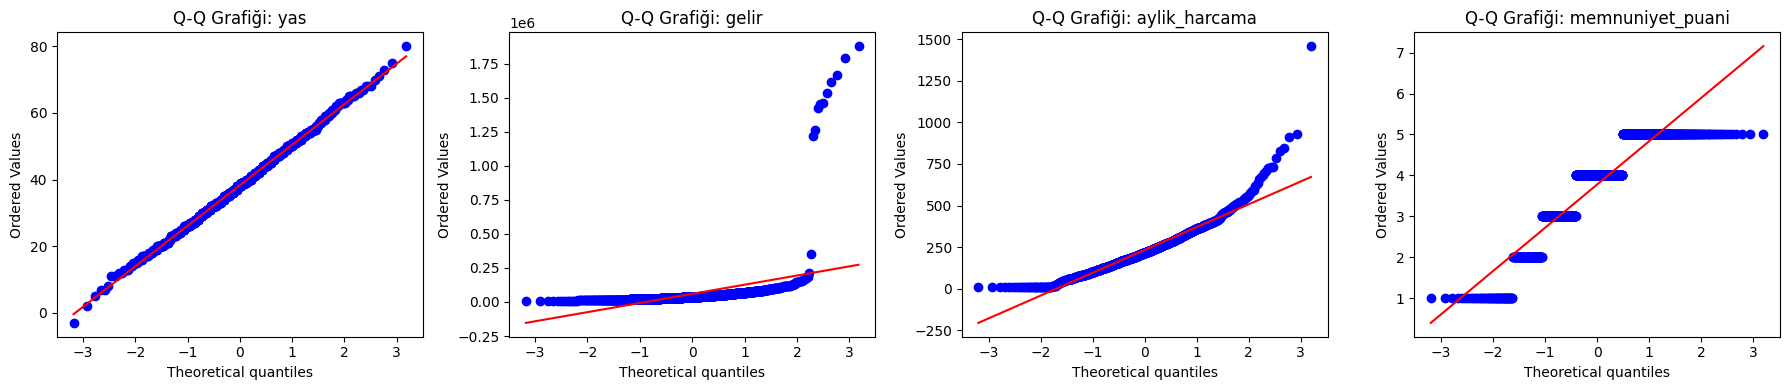

In [10]:
fig, axes = plt.subplots(1, len(sayisal_sutunlar), figsize=(18, 4))
for ax, col in zip(axes, sayisal_sutunlar):
    stats.probplot(df[col].dropna(), dist="norm", plot=ax) #df[col] → ilgili sütunu al , dropna() → eksik değerleri çıkar , dist="norm" → karşılaştırmayı normal dağılımla yap , plot=ax → sonucu ilgili grafiğe çiz
    ax.set_title(f"Q-Q Grafiği: {col}")
plt.tight_layout()
plt.show()

In [11]:
#İKİ GRUP KARŞILAŞTIRMASI
grup0= df.loc[df["churn"] == 0 , "aylik_harcama"].dropna()
grup1 = df.loc[df["churn"] == 1, "aylik_harcama"].dropna()

levene_stat, levene_p = stats.levene(grup0, grup1) # İki grubun harcamalarının yayılımı/varyansı birbirine benziyor mu?
print("Varsayımlar homojendir." if levene_p > 0.05 else "Varsayımlar homojen değildir.")
__, p0=stats.shapiro(grup0.sample(min(len(grup0),5000),random_state=0)) #__ → test istatistiği, kullanmıyoruz , p0 → p-değeri, bunu kullanıyoruz
__, p1=stats.shapiro(grup1.sample(min(len(grup1),5000),random_state=0))
normal_mi = (p0>0.05) and (p1>0.05)
print(f"grup normallik p değerleri: churn=0 -> {p0:.4f},churn=1 -> {p1:.4f}")


Varsayımlar homojendir.
grup normallik p değerleri: churn=0 -> 0.0000,churn=1 -> 0.0000


In [12]:
gruplar= [g["aylik_harcama"].dropna().values for _,g in df.groupby("abonelik_tipi")]

f_stat, anova_p = stats.f_oneway(*gruplar)
h_stat, kw_p= stats.kruskal(*gruplar)

print(f" tek yönlü anova: f={f_stat:.3f},p={anova_p:.4f}") #F değeri, gruplar arasındaki farklılığın, grupların kendi içindeki değişkenliğe göre ne kadar büyük olduğunu gösterir.
print(f"kruskal-wallis: h={h_stat:.3f},p={kw_p:.4f}")

 tek yönlü anova: f=3.175,p=0.0422
kruskal-wallis: h=9.289,p=0.0096


In [14]:
#Abonelik tipi ile aylık harcama arasındaki etki büyüklüğü yorumlanır.
genel_ortalama = df["aylik_harcama"].mean()
ss_between = sum(len(g)*(g.mean()-genel_ortalama)**2 for g in gruplar)
ss_total = sum((df["aylik_harcama"].dropna()-genel_ortalama)**2)
eta_kare = ss_between/ss_total
print(f"Eta Kare: {eta_kare:.4f} (0.01 küçük,0.06 orta, 0.14 büyük etki)")

Eta Kare: 0.0063 (0.01 küçük,0.06 orta, 0.14 büyük etki)


In [15]:
#post-hoc  true çıkarsa anlamlı fark var
tukey = pairwise_tukeyhsd(  #pairwise = ikili karşılaştırma
    endog=df["aylik_harcama"].dropna(),
    groups=df.loc[df["aylik_harcama"].notna(),"abonelik_tipi"], # notna: aylık harcaması boş olmayan satırların abonelik tiplerini getir
    alpha=0.05
)

print(tukey)

   Multiple Comparison of Means - Tukey HSD, FWER=0.05   
 group1   group2  meandiff p-adj   lower    upper  reject
---------------------------------------------------------
 Premium Standart  29.2666 0.0772  -2.4173 60.9506  False
 Premium    Temel  32.0392 0.0378   1.4135 62.6649   True
Standart    Temel   2.7725 0.9574 -20.3874 25.9325  False
---------------------------------------------------------


ANOVA<br>
↓<br>
Gruplar arasında fark var mı?<br>
↓<br>
EVET<br>
↓<br>
Tukey Post-Hoc<br>
↓<br>
Hangi gruplar arasında fark var?<br>
↓<br>
Temel ↔ Standart<br>
Temel ↔ Premium<br>
Standart ↔ Premium

In [20]:
# Kategorik Değişkenler Arasındaki İlişki
def cramers_v(x,y):
  tablo =pd.crosstab(x,y) #Çarpraz tablo oluşturuyoruz. Örneğin temel abonelikte churn değeri 0 ve 1 olanları görebilcez
  chi2 = stats.chi2_contingency(tablo)[0] #chi2_contingency() birkaç sonuç döndürür:chi2 ,p ,dof ,beklenen. Buradaki [0]: "Bana ilk sonucu, yani Chi-square değerini ver."
  n =tablo.sum().sum() #Müşteri sayısı
  k= min(tablo.shape)-1
  return np.sqrt(chi2/(n*k))

capraz = pd.crosstab(df["abonelik_tipi"],df["churn"])
chi2,p,dof,beklenen =stats.chi2_contingency(capraz)
v= cramers_v(df["abonelik_tipi"],df["churn"])
print(f"chi2={chi2:.4f},p={p:.4f},v={v:.4f}")
print(f"Cramer's V: {v:.4f}")
print("\n Çapraz Tablo")
print(capraz)

chi2=0.6105,p=0.7369,v=0.0246
Cramer's V: 0.0246

 Çapraz Tablo
churn            0   1
abonelik_tipi         
Premium        127  32
Standart       289  82
Temel          380  95


## **Korelasyon Analizi**
Korelasyon analizi, iki değişken arasındaki ilişkinin yönünü ve gücünü ölçmek için kullanılır.
Değişkenler birlikte artıyor mu, biri artarken diğeri azalıyor mu veya aralarında belirgin bir ilişki yok mu bunu gösterir.
Örneğin gelir ile aylık harcama arasında ilişki var mı sorusunu incelemek için kullanılabilir.


r → ilişkinin yönü ve gücü
<br>
p → ilişkinin istatistiksel olarak anlamlı olup olmadığı konusunda kanıt

In [18]:
 def  korelasyon_p_matrisi(veri,yontem ="pearson"):
  sutunlar = veri.columns

  #kat, korelasyon katsayılarını (r) saklayacak tablo.
  kat = pd.DataFrame(np.ones((len(sutunlar),len(sutunlar))),index=sutunlar,columns=sutunlar)

  #pval, p-değerlerini saklayacak.
  pval = pd.DataFrame(np.zeros((len(sutunlar),len(sutunlar))),index=sutunlar,columns=sutunlar)
  for i in sutunlar:
    for j in sutunlar:
      if i == j:
        kat.loc[i,j] = 1.0
        pval.loc[i,j] = 0.0
        continue
      ortak = veri[[i,j]].dropna()
      x_seri,y_seri = ortak.iloc[:,0],ortak.iloc[:,1]
      if yontem == "pearson":
        r,p = stats.pearsonr(x_seri,y_seri)
      else:
        r,p = stats.spearmanr(x_seri,y_seri)
      kat.loc[i,j] = float(r)
      pval.loc[i,j] = float(p)
  return kat,pval

pearson_r, pearson_p = korelasyon_p_matrisi(df[sayisal_sutunlar],"pearson")
print("--- pearson korelasyon katsayıları ---")
print(pearson_r)
print("\n--- pearson p değerleri ---")
print(pearson_p.round(4))

--- pearson korelasyon katsayıları ---
                       yas     gelir  aylik_harcama  memnuniyet_puani
yas               1.000000 -0.017131       0.032831         -0.017128
gelir            -0.017131  1.000000       0.078707          0.006980
aylik_harcama     0.032831  0.078707       1.000000          0.145050
memnuniyet_puani -0.017128  0.006980       0.145050          1.000000

--- pearson p değerleri ---
                     yas   gelir  aylik_harcama  memnuniyet_puani
yas               0.0000  0.6120         0.3108             0.597
gelir             0.6120  0.0000         0.0166             0.832
aylik_harcama     0.3108  0.0166         0.0000             0.000
memnuniyet_puani  0.5970  0.8320         0.0000             0.000


annot=True → sayıların hücre içinde görünmesini sağlar. <br>
fmt=".2f" → sayıları 2 ondalık gösterir. 0.4567 → 0.46<br>
center=0 → 0'ı merkeze alır.<br>
vmin=-1 → minimum korelasyon değeri<br>
vmax=1 → maksimum korelasyon değeri<br>
ax=axes[0] → ilk grafiğe çiz.<br>

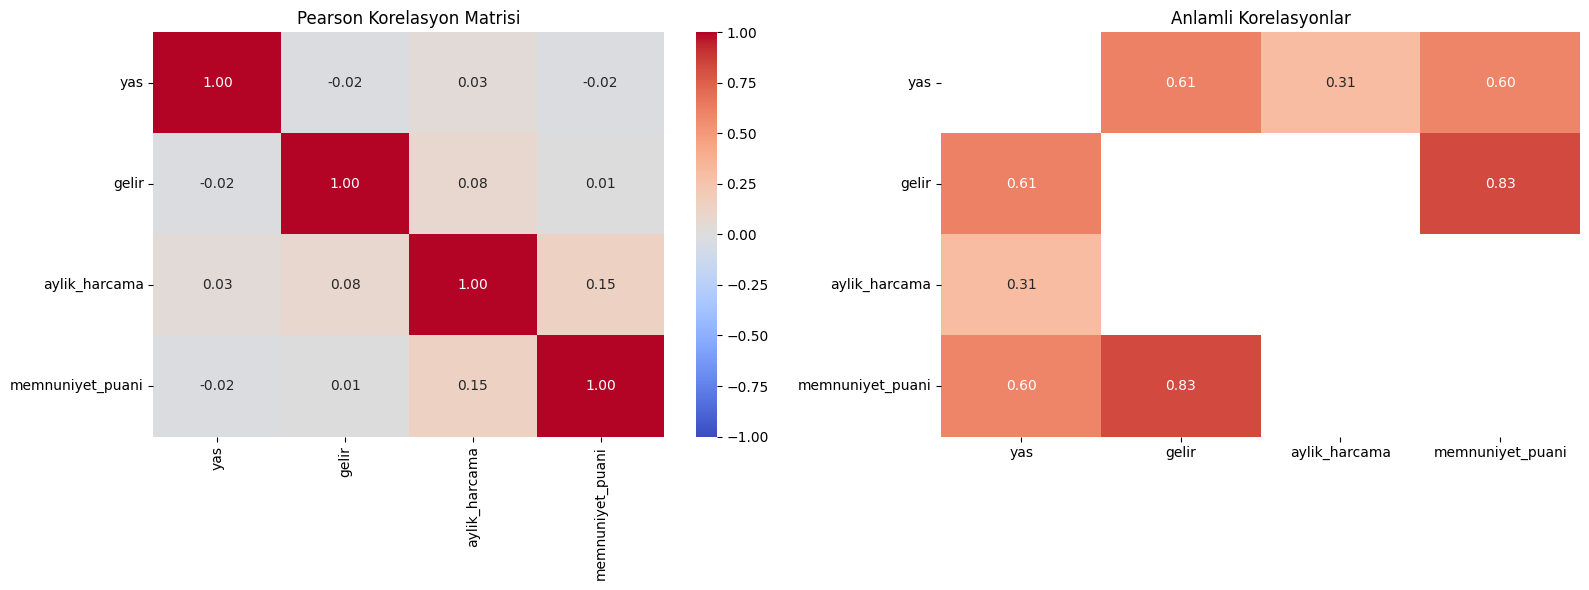

In [22]:
fig , axes = plt.subplots(1,2, figsize=(16,6)) #2 grafik alanı oluşturuluyor,1 satır,2 grafik,boyut
sns.heatmap(pearson_r,
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            center=0,
            vmin=-1,
            vmax=1,
            ax=axes[0])
axes[0].set_title("Pearson Korelasyon Matrisi")

#p > 0.05 olan korelasyonlar gösterilir, diğerleri gizlenir.
anlamli_maske = pearson_p > 0.05

sns.heatmap(pearson_p,
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            center=0,
            vmin=-1,
            vmax=1,
            mask=~anlamli_maske, #~ işareti burada True ↔ False tersine çeviriyor.
            ax=axes[1],
            cbar=False)
axes[1].set_title("Anlamli Korelasyonlar")
plt.tight_layout()
plt.show()

## **Çoklu Doğrusal Bağlantı(Multicollinerity)**


* VIF < 5 sorun yok rahatız

* 5 <VIF<10 dikkat

* VIF>10 yandı gülüm keten helva o değişkenlerle o iş olmaz

In [23]:
X_vif = df[["yas","gelir","memnuniyet_puani"]].dropna()
X_vif = sm.add_constant(X_vif)
vif_tablosu = pd.DataFrame({
    "Değişken":X_vif.columns,
    "VIF":[VIF(X_vif.values, i) for i in range(X_vif.shape[1])]
})
print(vif_tablosu)   # 1 yerine 0 dan başlattık



           Değişken       VIF
0             const  1.000000
1               yas  1.000948
2             gelir  1.000370
3  memnuniyet_puani  1.000739


In [24]:
X_vif = df[["yas", "gelir", "memnuniyet_puani"]].dropna()
X_vif_const = sm.add_constant(X_vif)

vif_tablosu = pd.DataFrame({
    "Değişken": X_vif.columns,
    "VIF": [VIF(X_vif_const.values, i) for i in range(1, X_vif_const.shape[1])]
})
print(vif_tablosu) # 0 index sabit değer çokta önemli değil onu yoksalım


           Değişken       VIF
0               yas  1.000948
1             gelir  1.000370
2  memnuniyet_puani  1.000739


In [25]:
X_vif = df[["yas", "gelir", "memnuniyet_puani"]].dropna()
X_vif = sm.add_constant(X_vif)

vif_tablosu = pd.DataFrame({
    "Değişken": [X_vif.columns[i]for i in range(1, X_vif.shape[1])],
    "VIF": [VIF(X_vif.values, i) for i in range(1, X_vif.shape[1])]
})
print(vif_tablosu)

# 4 değişken var  ilk indeksimizide 0 'dan 1 e çekelim


           Değişken       VIF
0               yas  1.000948
1             gelir  1.000370
2  memnuniyet_puani  1.000739


# **Keşifci Regresyon**

In [26]:
model_verisi = df[["aylik_harcama","gelir","memnuniyet_puani"]].dropna()
model_verisi = sm.add_constant(model_verisi)
model = smf.ols(formula="aylik_harcama~gelir+memnuniyet_puani",data=model_verisi)
sonuc = model.fit()
print(sonuc.summary())

                            OLS Regression Results                            
Dep. Variable:          aylik_harcama   R-squared:                       0.026
Model:                            OLS   Adj. R-squared:                  0.024
Method:                 Least Squares   F-statistic:                     12.20
Date:                Mon, 28 Sep 2026   Prob (F-statistic):           5.89e-06
Time:                        21:25:56   Log-Likelihood:                -5904.6
No. Observations:                 926   AIC:                         1.182e+04
Df Residuals:                     923   BIC:                         1.183e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept          163.3414     16.282  

## Temel Bileşenler Analizi(PCA)


In [27]:
pca_verisi = df[sayisal_sutunlar].dropna()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(pca_verisi)
pca = PCA()
X_pca = pca.fit_transform(X_scaled)
acıklanan_varyans = pca.explained_variance_ratio_
print(acıklanan_varyans)


[0.29064184 0.25339747 0.24789372 0.20806697]
